In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, classification_report
from sklearn.model_selection import TimeSeriesSplit
import warnings

In [2]:
# Ignore warnings from zero division in precision calculation for cleaner output
warnings.filterwarnings('ignore', category=UserWarning)

# Set pandas display options to easily view dataframes in the notebook
pd.set_option('display.max_columns', None)

In [3]:
def load_data(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath, parse_dates=['date'])
    df = df.sort_values('date').reset_index(drop=True)
    return df

# Load the data
FILE_PATH = './individual_stocks_5yr/AAP_data.csv'
raw_data = load_data(FILE_PATH)

print(f"Initial rows loaded: {len(raw_data)}")
raw_data.tail() # Inspect the last 5 rows

Initial rows loaded: 1259


,date,open,high,low,close,volume,Name
1254,2018-02-01,116.24,118.8300,115.830,117.29,760629,AAP
1255,2018-02-02,115.92,117.1800,113.125,113.93,1092333,AAP
1256,2018-02-05,113.05,114.9700,109.810,109.86,1281592,AAP
1257,2018-02-06,108.28,113.1100,106.745,112.20,1240784,AAP
1258,2018-02-07,112.09,114.5799,109.900,109.93,2163545,AAP


In [5]:
# Feature Engineering
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    # Drop rows with NaN values created by rolling windows
    df = df.dropna()

    # 1. Intra-day metrics
    df['Daily_Change'] = df['close'] - df['open']
    df['Daily_Range'] = df['high'] - df['low']

    # 2. Moving Averages (Trend indicators)
    df['SMA_10'] = df['close'].rolling(window=10).mean()
    df['SMA_50'] = df['close'].rolling(window=50).mean()

    # 3. Volume Metrics
    df['Vol_Avg_20'] = df['volume'].rolling(window=20).mean()
    df['Rel_Volume'] = df['volume'] / df['Vol_Avg_20']

    # 4. Momentum (Rolling returns)
    df['Return_5d'] = df['close'].pct_change(periods=5)
    df['Return_20d'] = df['close'].pct_change(periods=20)

    # 5. Create Target Variable (1 if tomorrow closes higher than today, else 0)
    df['Tomorrow_Close'] = df['close'].shift(-1)
    df['Target'] = (df['Tomorrow_Close'] > df['close']).astype(int)

    return df

processed_data = engineer_features(raw_data.copy())

print(f"Rows remaining after feature engineering: {len(processed_data)}")
processed_data.tail() # Inspect the data with new features


Rows remaining after feature engineering: 1259


,date,open,high,low,close,volume,Name,Daily_Change,Daily_Range,SMA_10,SMA_50,Vol_Avg_20,Rel_Volume,Return_5d,Return_20d,Tomorrow_Close,Target
1254,2018-02-01,116.24,118.8300,115.830,117.29,760629,AAP,1.05,3.0000,119.614,105.8292,1340796.80,0.567296,-0.030020,0.095656,113.93,0
1255,2018-02-02,115.92,117.1800,113.125,113.93,1092333,AAP,-1.99,4.0550,119.305,106.2792,1290189.65,0.846645,-0.078534,0.026396,109.86,0
1256,2018-02-05,113.05,114.9700,109.810,109.86,1281592,AAP,-3.19,5.1600,118.488,106.6978,1254436.35,1.021648,-0.106030,-0.020681,112.20,1
1257,2018-02-06,108.28,113.1100,106.745,112.20,1240784,AAP,3.92,6.3650,117.798,107.1494,1253620.05,0.989761,-0.059277,0.007272,109.93,0
1258,2018-02-07,112.09,114.5799,109.900,109.93,2163545,AAP,-2.16,4.6799,116.692,107.5634,1307226.15,1.655066,-0.060347,-0.005068,NaN,0


In [6]:
# Model Training & Evaluation (Time Series Cross-Validation)
# Because this is time-series data, a standard random train/test split would cause data leakage.
# We use `TimeSeriesSplit` to train on a rolling historical window and test on the subsequent forward window.

# Define the features to use (exclude metadata and target-related columns)
features = [
    'open', 'high', 'low', 'close', 'volume',
    'Daily_Change', 'Daily_Range', 'SMA_10', 'SMA_50',
    'Rel_Volume', 'Return_5d', 'Return_20d'
]

X = processed_data[features]
y = processed_data['Target']

# Initialize Time Series Splitter
tscv = TimeSeriesSplit(n_splits=5)

precision_scores = []
accuracy_scores = []

print("--- Training and Evaluating over 5 Time Periods ---\n")

for fold, (train_index, test_index) in enumerate(tscv.split(X), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Use class_weight='balanced' to prevent the model from blindly guessing the majority class
    model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions, zero_division=0)

    accuracy_scores.append(acc)
    precision_scores.append(prec)

    print(f"Fold {fold} - Accuracy: {acc*100:.2f}%, Precision: {prec*100:.2f}%")

print("\n--- Final Aggregated Results ---")
print(f"Average Accuracy:  {np.mean(accuracy_scores) * 100:.2f}%")
print(f"Average Precision: {np.mean(precision_scores) * 100:.2f}%")

--- Training and Evaluating over 5 Time Periods ---

Fold 1 - Accuracy: 50.72%, Precision: 50.53%
Fold 2 - Accuracy: 40.67%, Precision: 0.00%
Fold 3 - Accuracy: 52.63%, Precision: 50.86%
Fold 4 - Accuracy: 48.33%, Precision: 43.31%
Fold 5 - Accuracy: 49.76%, Precision: 49.68%

--- Final Aggregated Results ---
Average Accuracy:  48.42%
Average Precision: 38.88%


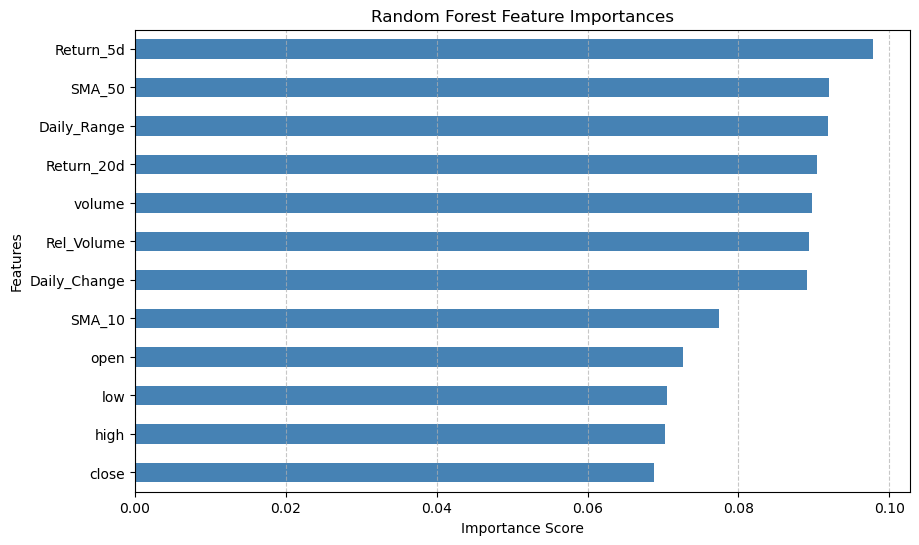

In [7]:
# Feature Importance Analysis
# Train a model on the entire dataset to extract the feature importances,
# showing which technical indicators the Random Forest found most predictive.

# Train one final model on the ENTIRE dataset
final_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
final_model.fit(X, y)

# Extract and plot feature importances
importances = pd.Series(final_model.feature_importances_, index=features).sort_values(ascending=True)

# Plotting directly in the notebook
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()